In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Number of GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Current GPU device:", torch.cuda.current_device())


CUDA available: True
Number of GPUs: 1
Current GPU device: 0


Raw x shape (NumPy): (12, 288, 288)


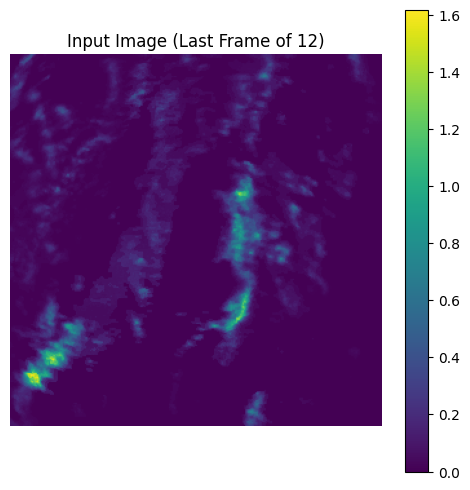

In [3]:
import torch
import matplotlib.pyplot as plt
from utils import dataset_precip  # Adjust import as needed

# ----- Load Sample from Dataset -----
dataset = dataset_precip.precipitation_maps_oversampled_h5(
    in_file="data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5",
    num_input_images=12,
    num_output_images=6,
    train=False
)

# Load sample 1337: this returns (x, y_true)
# Here, x is a NumPy array of shape [12, H, W]
x, y_true = dataset[1337]

print("Raw x shape (NumPy):", x.shape)

# Convert the input x to a tensor for model inference.
input_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # shape: [1, 12, H, W]
input_tensor = input_tensor.cuda()

# For the display image, use the last input frame (channel index 11):
display_image = torch.tensor(x, dtype=torch.float32)[-1]  # shape: [H, W]
display_image = display_image * 47.83  # Apply scaling if needed

plt.figure(figsize=(6, 6))
plt.imshow(display_image.detach().cpu().numpy(), cmap='viridis')
plt.title("Input Image (Last Frame of 12)")
plt.axis("off")
plt.colorbar()
plt.show()

In [4]:
# Cell: visualize_gradcam.ipynb
import torch
import argparse
import matplotlib.pyplot as plt

# Import your GradCAM definitions
from gradcamdefinition import GradCAM, show_heatmap_on_image

# Import your model definition.
# Adjust the import according to your project structure.
from models import SmaAT_UNet_VQ_lightning  
# Your model class is defined inside SmaAT_UNet_VQ_lightning, so:
SmaAT_UNet_VQ = SmaAT_UNet_VQ_lightning.SmaAT_UNet_VQ

# Define the required hyperparameters.
# These are the ones you used during training.
hparams = argparse.Namespace(
    model="SmaAT_UNet_VQ_MSE",      # Your model type (here using the MSE variant)
    n_channels=12,                  # 12 input satellite images
    n_classes=1,                    # For MSE, continuous output (for CE, you’d use 15)
    bilinear=True,                  # Your architecture setting
    reduction_ratio=16,             # For the CBAM modules
    kernels_per_layer=2,            # As set in your training script
    vq_num_embeddings=32,           # From your checkpoint name, e.g., "num32"
    vq_commitment_cost=0.75,        # From your checkpoint name "commit0.75"
    vqmodel_recon_loss_type="mse",   # Using MSE variant in this example
    # (Other hyperparameters, such as learning rate or epochs, are not needed for inference)
)

# Specify the path to your trained model checkpoint.
checkpoint_path = "best_results/SmaAT_UNet_VQ_MSE-num32-commit0.75_rain_threshold_50_epoch=74-val_total_loss=0.183429.ckpt"

# Load the model from the checkpoint.
model = SmaAT_UNet_VQ.load_from_checkpoint(checkpoint_path, hparams=hparams)
model.cuda()
model.eval()

/home/nstavrou/.local/lib/python3.11/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.2.5, which is newer than your current Lightning version: v2.2.1


SmaAT_UNet_VQ(
  (inc): DoubleConvDS(
    (double_conv): Sequential(
      (0): DepthwiseSeparableConv(
        (depthwise): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=12)
        (pointwise): Conv2d(24, 64, kernel_size=(1, 1), stride=(1, 1))
      )
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): DepthwiseSeparableConv(
        (depthwise): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
        (pointwise): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
      )
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (cbam1): CBAM(
    (channel_att): ChannelAttention(
      (avg_pool): AdaptiveAvgPool2d(output_size=1)
      (max_pool): AdaptiveMaxPool2d(output_size=1)
      (MLP): Sequential(
        (0): Flatten()
        (1): Linear(in_features=64, out_features=

/home/nstavrou/.local/lib/python3.11/site-packages/torch/nn/modules/module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
/home/nstavrou/.local/lib/python3.11/site-packages/torch/nn/modules/module.py:1317: UserWarning: Using non-full backward hooks on a Module that does not return a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_output. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not return a "


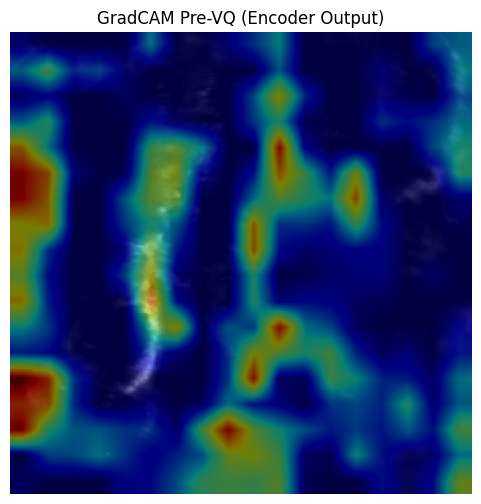

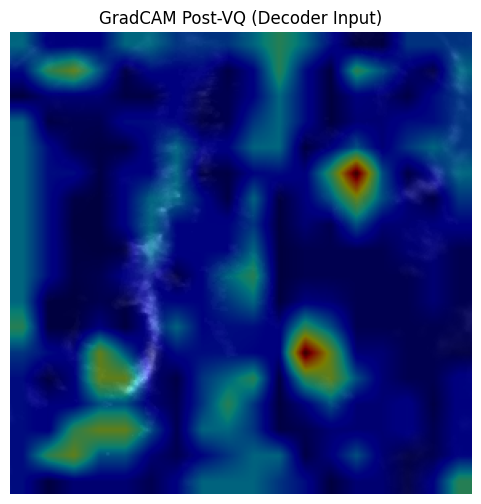

In [10]:
# Not used anymore
# For a single depth

# Instantiate GradCAM for the desired target layers.
# For pre-VQ visualization, we'll use the output of the CBAM module (model.cbam5)
# For post-VQ visualization, we'll use the output of the VQ module (model.vq)
gradcam_preVQ = GradCAM(model, target_layer=model.cbam5)
gradcam_postVQ = GradCAM(model, target_layer=model.vq)

# Generate GradCAM heatmaps.
heatmap_pre = gradcam_preVQ(input_tensor)
heatmap_post = gradcam_postVQ(input_tensor)

# Remove hooks once done.
gradcam_preVQ.remove_hooks()
gradcam_postVQ.remove_hooks()

# Visualize the heatmaps on top of the input image.
# Here we use only the first channel (assuming that's sufficient for display).
show_heatmap_on_image(input_tensor[0, 0:1, :, :], heatmap_pre[0], "GradCAM Pre-VQ (Encoder Output)")
show_heatmap_on_image(input_tensor[0, 0:1, :, :], heatmap_post[0], "GradCAM Post-VQ (Decoder Input)")

/home/nstavrou/.local/lib/python3.11/site-packages/torch/nn/modules/module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


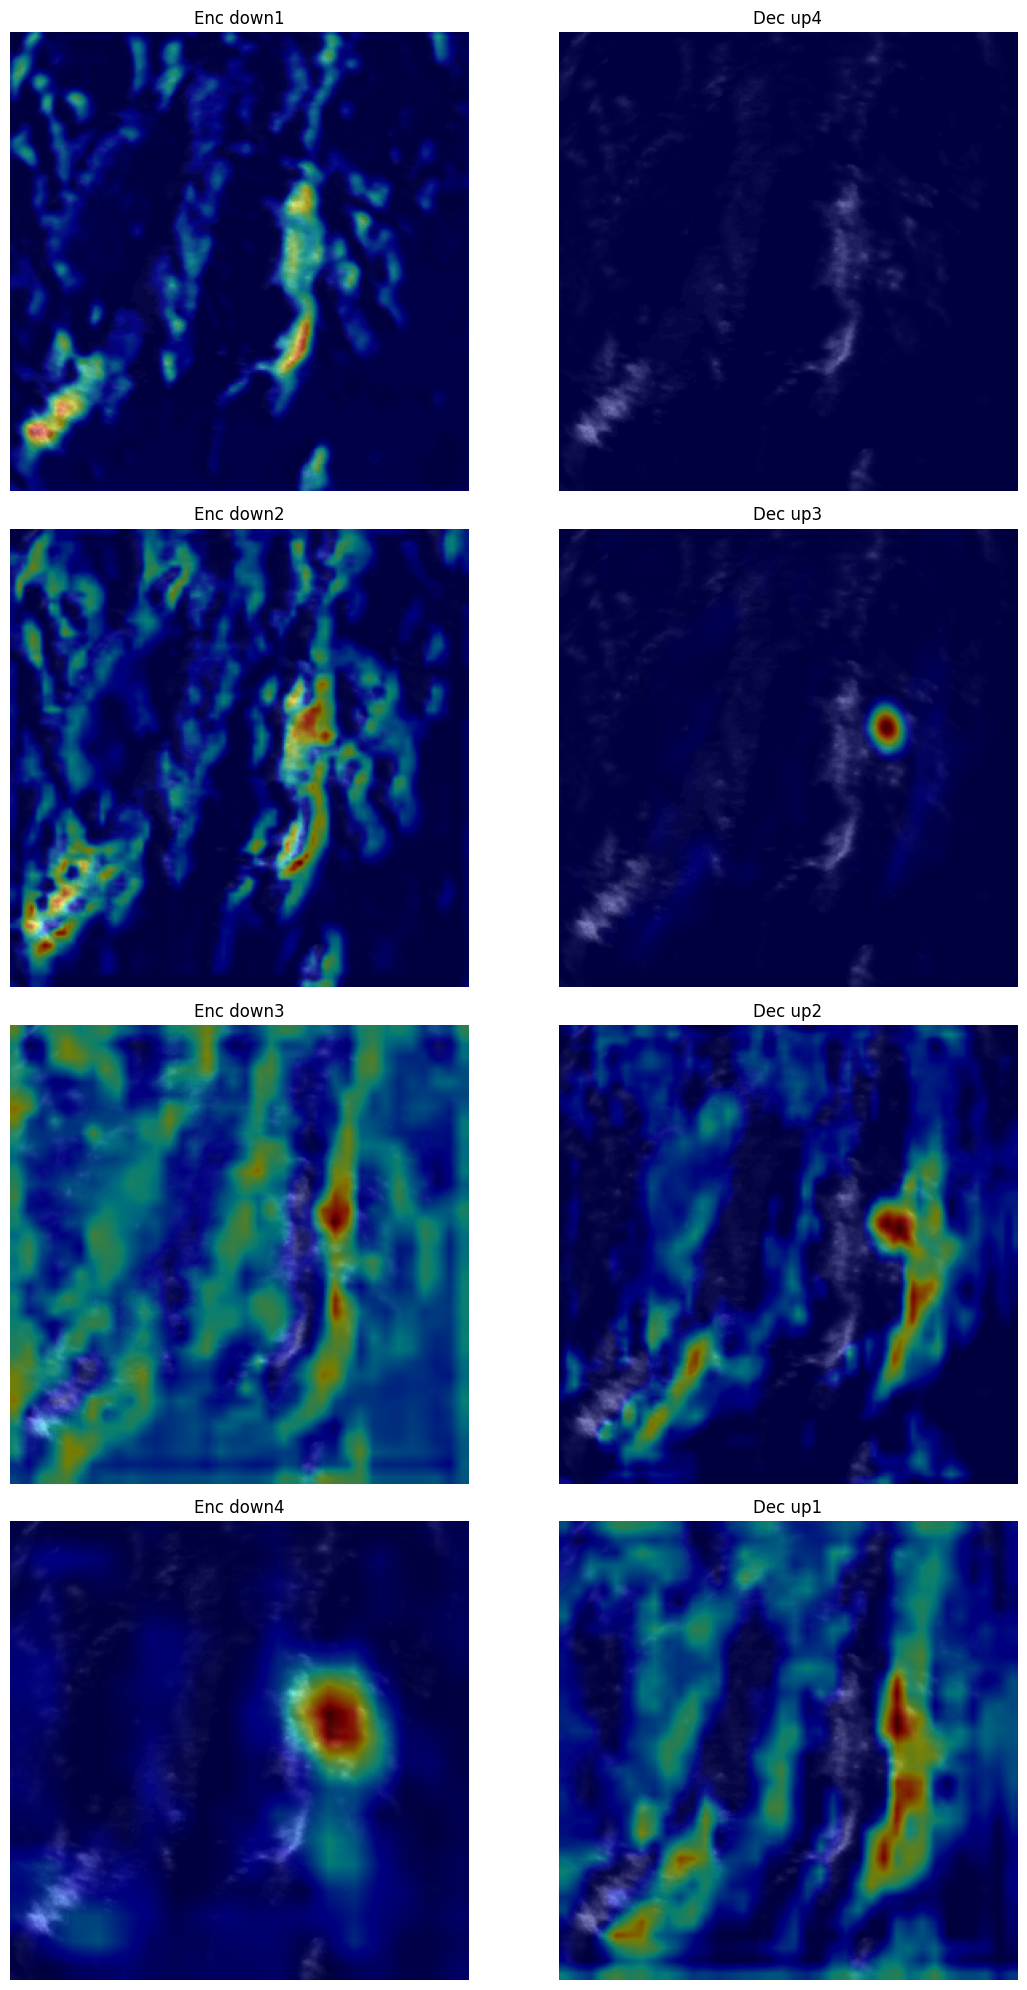

In [12]:
import matplotlib.pyplot as plt

# Define the four matching pairs (encoder down_i with decoder up_{5-i})
pairs = [
    ("Enc down1", model.down1, "Dec up4", model.up4),
    ("Enc down2", model.down2, "Dec up3", model.up3),
    ("Enc down3", model.down3, "Dec up2", model.up2),
    ("Enc down4", model.down4, "Dec up1", model.up1),
]

# Prepare a 4×2 grid
rows = len(pairs)
cols = 2
plt.figure(figsize=(6 * cols, 5 * rows))

for i, (enc_name, enc_mod, dec_name, dec_mod) in enumerate(pairs, 1):
    # Encoder GradCAM
    cam_enc = GradCAM(model, target_layer=enc_mod)
    heat_enc = cam_enc(input_tensor)[0].cpu().numpy().squeeze()
    cam_enc.remove_hooks()
    
    # Decoder GradCAM
    cam_dec = GradCAM(model, target_layer=dec_mod)
    heat_dec = cam_dec(input_tensor)[0].cpu().numpy().squeeze()
    cam_dec.remove_hooks()
    
    # Plot encoder heatmap
    plt.subplot(rows, cols, (i - 1) * cols + 1)
    plt.imshow(display_image.cpu().numpy(), cmap="gray")
    plt.imshow(heat_enc, cmap="jet", alpha=0.5)
    plt.title(enc_name)
    plt.axis("off")
    
    # Plot decoder heatmap
    plt.subplot(rows, cols, (i - 1) * cols + 2)
    plt.imshow(display_image.cpu().numpy(), cmap="gray")
    plt.imshow(heat_dec, cmap="jet", alpha=0.5)
    plt.title(dec_name)
    plt.axis("off")

plt.tight_layout()
plt.show()


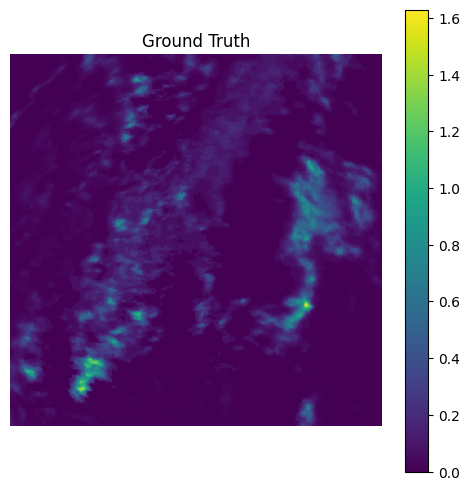

In [12]:
import torch
import matplotlib.pyplot as plt
from utils import dataset_precip  # Adjust the import path as needed

# Load the dataset using your dataset_precip loader.
dataset = dataset_precip.precipitation_maps_oversampled_h5(
    in_file="data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5",
    num_input_images=12,
    num_output_images=6,
    train=False
)

# Get a specific sample (for example, sample index 1337)
x, y_true = dataset[1337]

# Convert the ground-truth image to a torch tensor and add a batch dimension
y_true = torch.tensor(y_true, dtype=torch.float32).unsqueeze(0)

# Plot the ground truth image (as in your previous notebook)
plt.figure(figsize=(6, 6))
plt.imshow(y_true.squeeze() * 47.83, cmap='viridis')
plt.colorbar()
plt.title("Ground Truth")
plt.axis("off")
plt.show()
